In [2]:
import xarray as xr
import torch as tr
import pandas as pd
import numpy as np

In [12]:
file_path = '/Users/lenovo/Desktop/GRIPS2026_Project/raw_data/meteodata/20250101.nc'
ds = xr.open_dataset(file_path)
print(ds)
arr = ds["data"]

value = arr.isel(
    time=0,
    lead_time=6,
    channel=2,
    lat=60,
    lon=140
).values

print(value)
#print(float(value.values))

<xarray.Dataset> Size: 31MB
Dimensions:    (time: 1, lead_time: 24, channel: 7, lat: 104, lon: 225)
Coordinates:
  * time       (time) datetime64[ns] 8B 2025-01-01T16:00:00
  * lead_time  (lead_time) int64 192B 0 1 2 3 4 5 6 7 ... 17 18 19 20 21 22 23
  * channel    (channel) <U4 112B 'ghi' 'sp' 't2m' 'tcc' 'tp' 'u100' 'v100'
  * lat        (lat) float64 832B 46.5 46.4 46.3 46.2 ... 36.5 36.4 36.3 36.2
  * lon        (lon) float64 2kB 96.1 96.2 96.3 96.4 ... 118.2 118.3 118.4 118.5
Data variables:
    data       (time, lead_time, channel, lat, lon) float64 31MB ...
260.770751953125


## Boundary feature distributions over time

The boundary data is recorded at 15-minute intervals, so plotting every point can hide the overall pattern. The cells below create one plot per variable using a daily median line plus the daily interquartile range (25th–75th percentile). Actual values use a solid blue line; forecast values use a dashed orange line.

In [16]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("/Users/lenovo/Desktop/GRIPS2026_Project/raw_data/train/mengxi_boundary_anon_filtered.csv")
PLOT_DIR = Path("/Users/lenovo/Desktop/GRIPS2026_Project/figures/boundary_distributions")

# Change this if you want a finer/coarser view, e.g. "6H" or "W".
SUMMARY_FREQ = "D"

features = pd.read_csv(DATA_PATH)
time_col = "times" if "times" in features.columns else "time"
features[time_col] = pd.to_datetime(features[time_col])
features = features.sort_values(time_col)

features.head()

Matplotlib is building the font cache; this may take a moment.


,times,System_Load_Actual_Value,System_Load_Forecast_Value,Wind_And_Solar_Actual_Value,Wind_And_Solar_Forecast_Value,Tie_Line_Actual_Value,Tie_Line_Forecast_Value,Wind_Power_Actual_Value,Wind_Power_Forecast_Value,Photovoltaic_Actual_Value,Photovoltaic_Forecast_Value,Hydropower_Actual_Value,Hydropower_Forecast_Value,Non-Marketized_Unit_Actual_Value,Non-Marketized_Unit_Forecast_Value
0,2025-01-01 00:15:00,3.018450,3.014761,0.470225,0.543618,0.111842,0.147271,0.479659,0.542054,-0.009434,0.001565,-0.009010,0.090382,0.404636,0.509081
1,2025-01-01 00:30:00,3.009087,3.011324,0.494797,0.551016,0.123568,0.147271,0.504262,0.549180,-0.009465,0.001836,-0.030981,0.048798,0.383877,0.471520
2,2025-01-01 00:45:00,3.015343,3.008533,0.504551,0.564128,0.119341,0.147271,0.514061,0.562018,-0.009510,0.002110,-0.036142,0.008617,0.378804,0.434760
3,2025-01-01 01:00:00,3.015672,3.004284,0.507104,0.577606,0.113778,0.147271,0.516654,0.575220,-0.009551,0.002385,-0.048198,0.023098,0.370650,0.452589
4,2025-01-01 01:15:00,3.006780,3.002369,0.531630,0.587884,0.108895,0.147271,0.541460,0.585500,-0.009831,0.002384,-0.049977,0.035371,0.374129,0.465573


In [17]:
ACTUAL_SUFFIX = "_Actual_Value"
FORECAST_SUFFIX = "_Forecast_Value"

actual_cols = {
    col.removesuffix(ACTUAL_SUFFIX): col
    for col in features.columns
    if col.endswith(ACTUAL_SUFFIX)
}
forecast_cols = {
    col.removesuffix(FORECAST_SUFFIX): col
    for col in features.columns
    if col.endswith(FORECAST_SUFFIX)
}

variable_pairs = [
    (base, actual_cols[base], forecast_cols[base])
    for base in sorted(actual_cols.keys() & forecast_cols.keys())
]

unpaired_actual = sorted(actual_cols.keys() - forecast_cols.keys())
unpaired_forecast = sorted(forecast_cols.keys() - actual_cols.keys())

print(f"Detected {len(variable_pairs)} actual/forecast variable pairs.")
if unpaired_actual:
    print("Actual columns without forecast pair:", unpaired_actual)
if unpaired_forecast:
    print("Forecast columns without actual pair:", unpaired_forecast)

pd.DataFrame(variable_pairs, columns=["variable", "actual_column", "forecast_column"])

Detected 7 actual/forecast variable pairs.


,variable,actual_column,forecast_column
0,Hydropower,Hydropower_Actual_Value,Hydropower_Forecast_Value
1,Non-Marketized_Unit,Non-Marketized_Unit_Actual_Value,Non-Marketized_Unit_Forecast_Value
2,Photovoltaic,Photovoltaic_Actual_Value,Photovoltaic_Forecast_Value
3,System_Load,System_Load_Actual_Value,System_Load_Forecast_Value
4,Tie_Line,Tie_Line_Actual_Value,Tie_Line_Forecast_Value
5,Wind_And_Solar,Wind_And_Solar_Actual_Value,Wind_And_Solar_Forecast_Value
6,Wind_Power,Wind_Power_Actual_Value,Wind_Power_Forecast_Value


In [18]:
def summarize_distribution(df, value_col, freq=SUMMARY_FREQ):
    return (
        df.set_index(time_col)[value_col]
        .resample(freq)
        .agg(
            q25=lambda values: values.quantile(0.25),
            median="median",
            q75=lambda values: values.quantile(0.75),
        )
        .dropna(how="all")
    )


def readable_name(name):
    return name.replace("_", " ").replace("-", " ")


def safe_filename(name):
    return "".join(char if char.isalnum() or char in "._-" else "_" for char in name)


def plot_actual_vs_forecast(df, variable, actual_col, forecast_col, save_dir=PLOT_DIR):
    actual_summary = summarize_distribution(df, actual_col)
    forecast_summary = summarize_distribution(df, forecast_col)

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        actual_summary.index,
        actual_summary["median"],
        color="#1f77b4",
        linestyle="-",
        linewidth=1.8,
        label="Actual median",
    )
    ax.fill_between(
        actual_summary.index,
        actual_summary["q25"].to_numpy(),
        actual_summary["q75"].to_numpy(),
        color="#1f77b4",
        alpha=0.16,
        linewidth=0,
        label="Actual IQR",
    )

    ax.plot(
        forecast_summary.index,
        forecast_summary["median"],
        color="#ff7f0e",
        linestyle="--",
        linewidth=1.8,
        label="Forecast median",
    )
    ax.fill_between(
        forecast_summary.index,
        forecast_summary["q25"].to_numpy(),
        forecast_summary["q75"].to_numpy(),
        color="#ff7f0e",
        alpha=0.16,
        linewidth=0,
        label="Forecast IQR",
    )

    ax.set_title(f"{readable_name(variable)}: actual vs forecast ({SUMMARY_FREQ} median and IQR)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.25)
    ax.legend(ncols=2)
    fig.autofmt_xdate()
    fig.tight_layout()

    save_dir.mkdir(parents=True, exist_ok=True)
    output_path = save_dir / f"{safe_filename(variable)}.png"
    fig.savefig(output_path, dpi=160)
    return fig, output_path

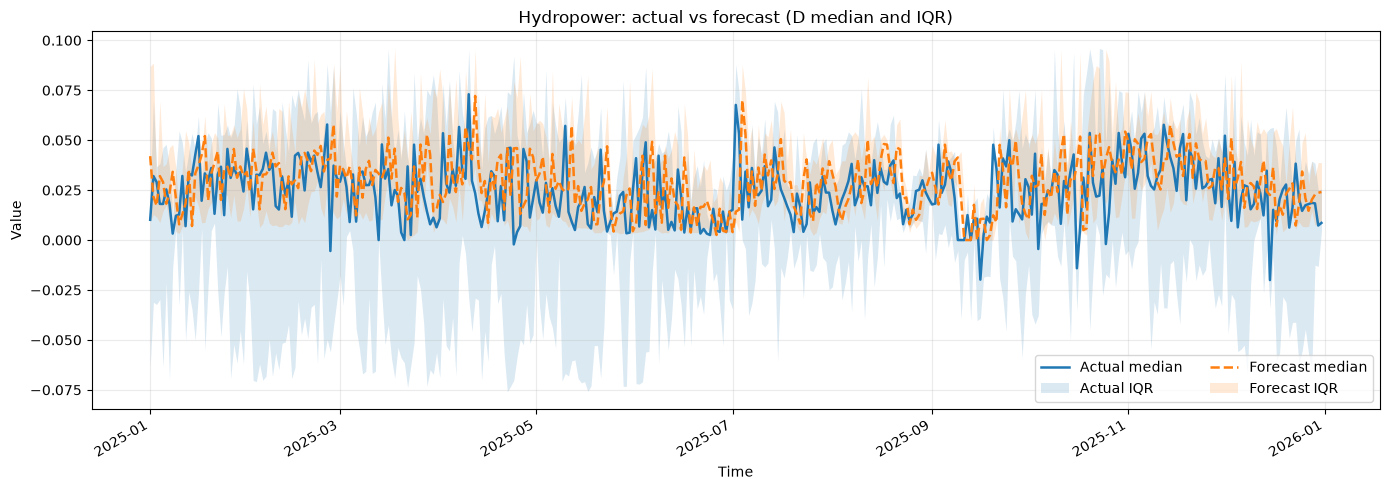

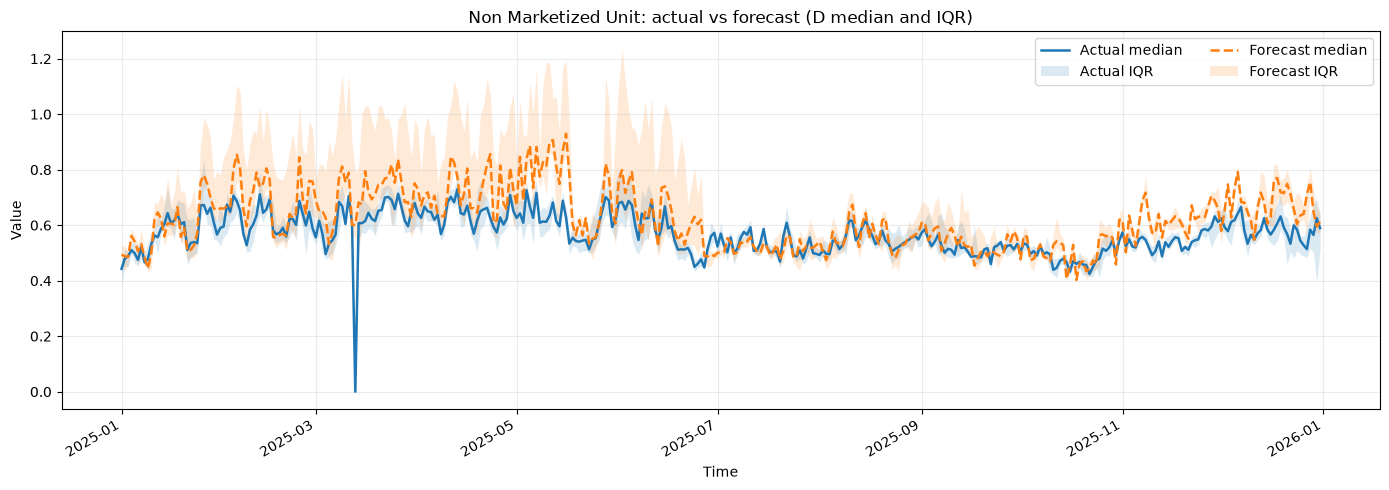

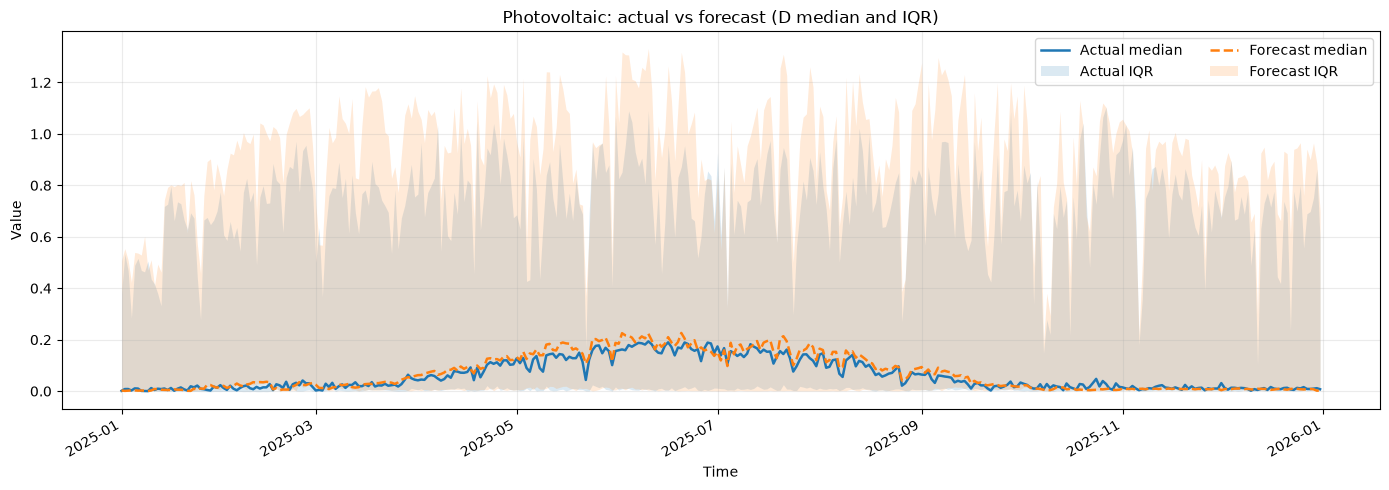

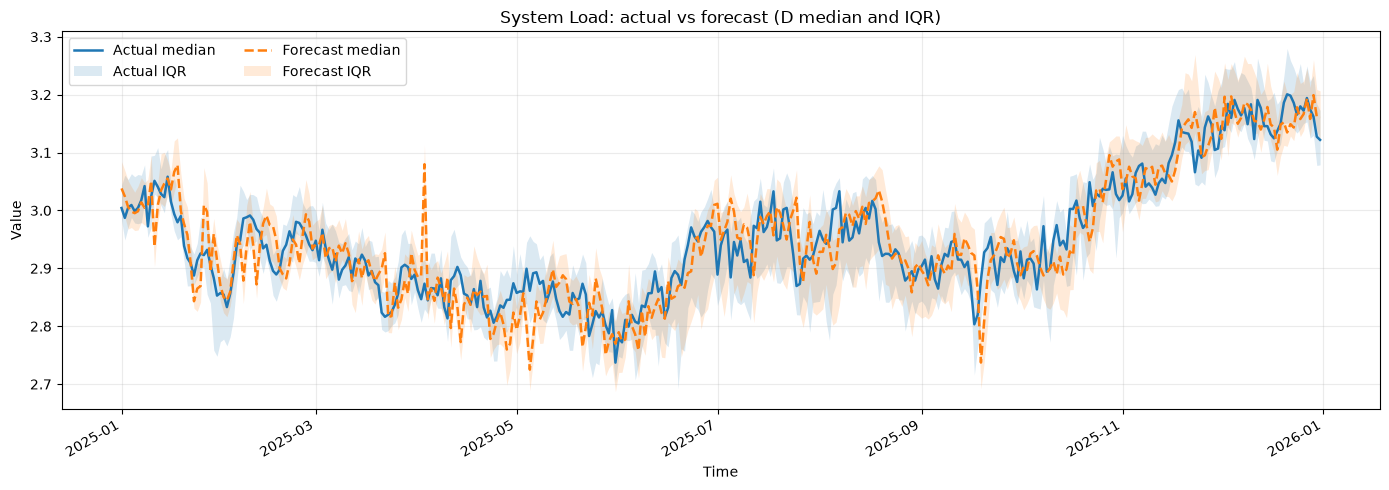

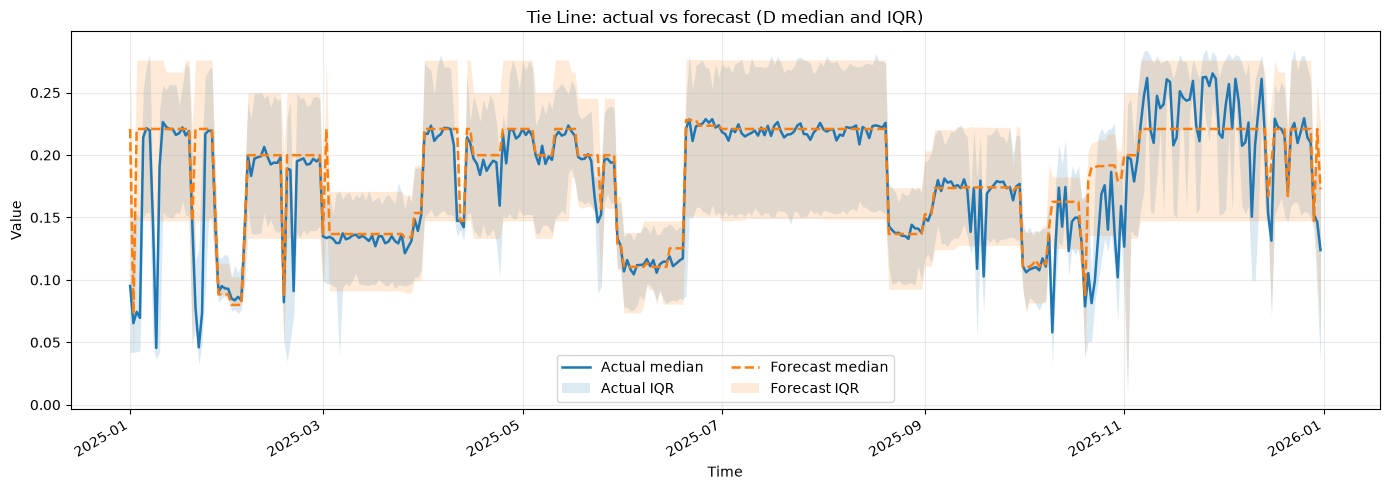

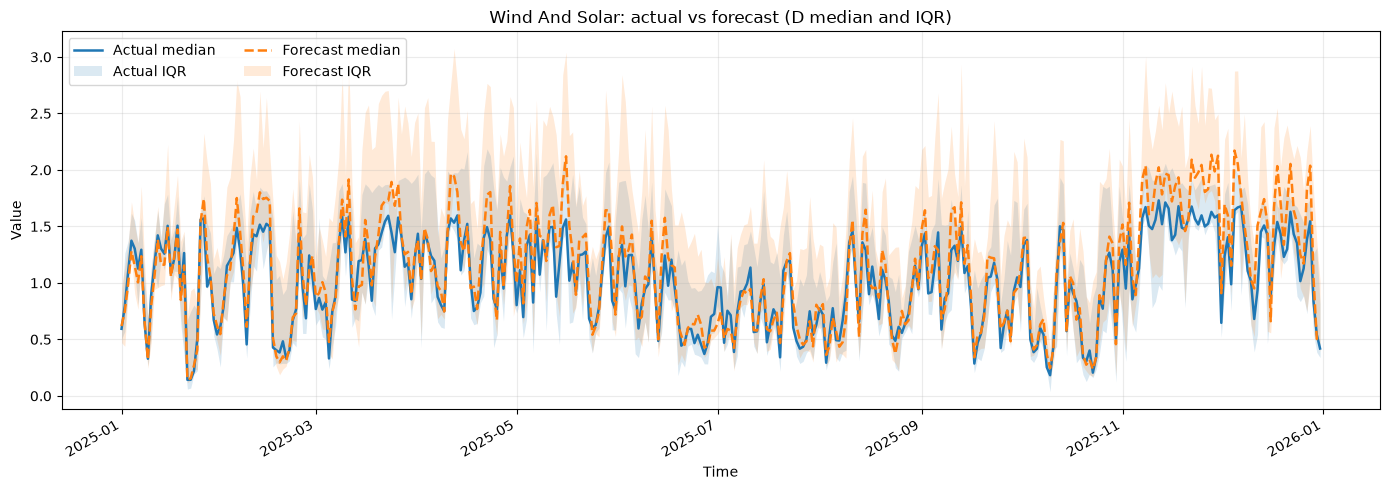

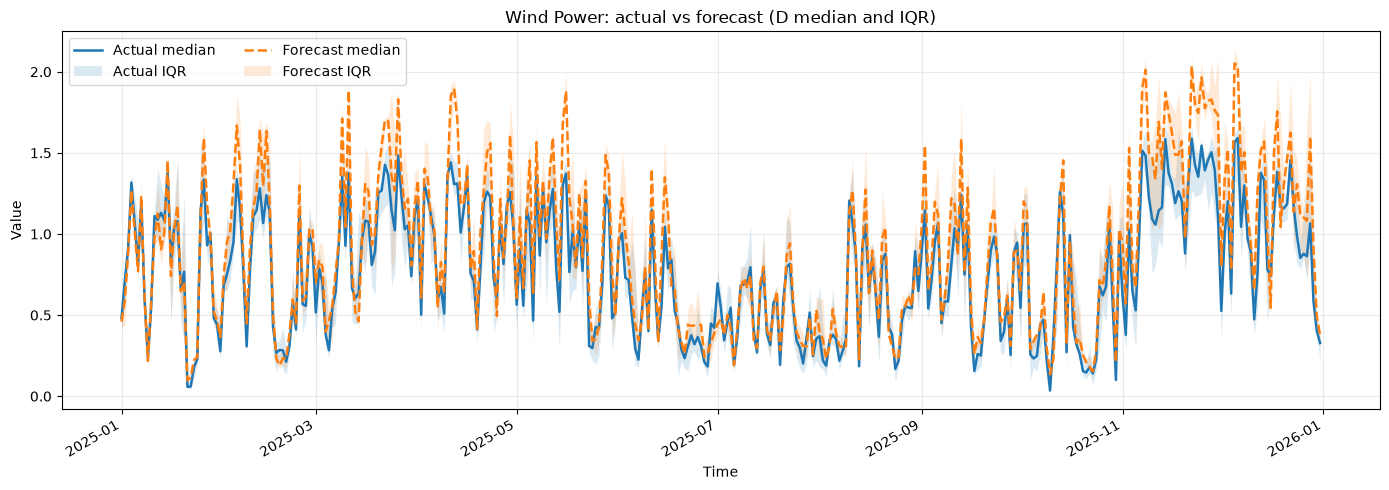

Saved plots:
/Users/lenovo/Desktop/GRIPS2026_Project/figures/boundary_distributions/Hydropower.png
/Users/lenovo/Desktop/GRIPS2026_Project/figures/boundary_distributions/Non-Marketized_Unit.png
/Users/lenovo/Desktop/GRIPS2026_Project/figures/boundary_distributions/Photovoltaic.png
/Users/lenovo/Desktop/GRIPS2026_Project/figures/boundary_distributions/System_Load.png
/Users/lenovo/Desktop/GRIPS2026_Project/figures/boundary_distributions/Tie_Line.png
/Users/lenovo/Desktop/GRIPS2026_Project/figures/boundary_distributions/Wind_And_Solar.png
/Users/lenovo/Desktop/GRIPS2026_Project/figures/boundary_distributions/Wind_Power.png


In [19]:
saved_plots = []

for variable, actual_col, forecast_col in variable_pairs:
    fig, output_path = plot_actual_vs_forecast(features, variable, actual_col, forecast_col)
    saved_plots.append(output_path)
    plt.show()

print("Saved plots:")
for path in saved_plots:
    print(path)

## Photovoltaic actual vs forecast: daily mean and seasonal 15-minute zoom

This section focuses only on `Photovoltaic_Actual_Value` and `Photovoltaic_Forecast_Value`. It creates two plots: one using the daily mean, and one zooming into July and December with the original 15-minute observations.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_file(relative_path):
    relative_path = Path(relative_path)
    for base_path in [Path.cwd(), *Path.cwd().parents]:
        candidate = base_path / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {relative_path} from current directory: {Path.cwd()}")


PV_DATA_PATH = find_project_file("raw_data/targets/preduction.csv")
PROJECT_ROOT = PV_DATA_PATH.parents[2]
PV_PLOT_DIR = PROJECT_ROOT / "output" / "EDA_figures" / "photovoltaic"
PV_PLOT_DIR.mkdir(parents=True, exist_ok=True)

TIME_COL = "times"
PV_ACTUAL_COL = "Photovoltaic_Actual_Value"
PV_FORECAST_COL = "Photovoltaic_Forecast_Value"
PV_COLS = [PV_ACTUAL_COL, PV_FORECAST_COL]

pv_df = pd.read_csv(PV_DATA_PATH)
missing_cols = [col for col in [TIME_COL, *PV_COLS] if col not in pv_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

pv_df[TIME_COL] = pd.to_datetime(pv_df[TIME_COL])
for col in PV_COLS:
    pv_df[col] = pd.to_numeric(pv_df[col], errors="coerce")

pv_df = pv_df[[TIME_COL, *PV_COLS]].sort_values(TIME_COL).dropna(subset=[TIME_COL])

print(f"Loaded: {PV_DATA_PATH}")
print(f"Rows: {len(pv_df):,}")
print(f"Time range: {pv_df[TIME_COL].min()} to {pv_df[TIME_COL].max()}")
pv_df.head()

Loaded: /Users/lenovo/Desktop/GRIPS2026_Project/raw_data/targets/preduction.csv
Rows: 35,039
Time range: 2025-01-01 00:15:00 to 2025-12-31 23:45:00


,times,Photovoltaic_Actual_Value,Photovoltaic_Forecast_Value
0,2025-01-01 00:15:00,-0.009434,0.001565
1,2025-01-01 00:30:00,-0.009465,0.001836
2,2025-01-01 00:45:00,-0.009510,0.002110
3,2025-01-01 01:00:00,-0.009551,0.002385
4,2025-01-01 01:15:00,-0.009831,0.002384


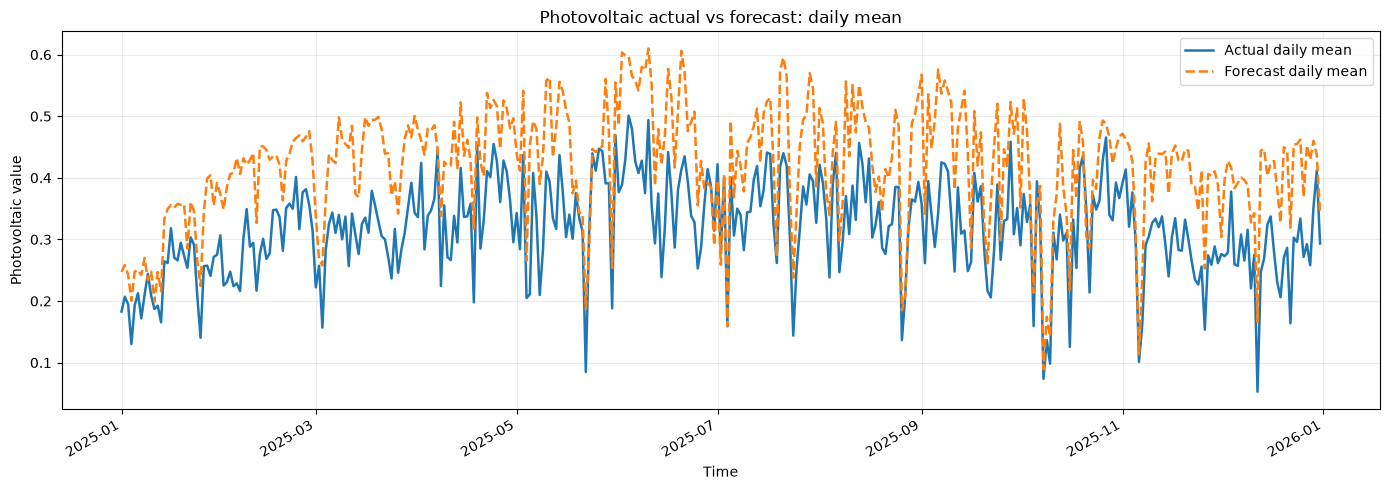

Saved: /Users/lenovo/Desktop/GRIPS2026_Project/output/EDA_figures/photovoltaic/photovoltaic_daily_mean.png


In [5]:
# Plot 1: daily mean of photovoltaic actual and forecast values.

pv_daily_mean = (
    pv_df.set_index(TIME_COL)[PV_COLS]
    .resample("D")
    .mean()
    .dropna(how="all")
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    pv_daily_mean.index,
    pv_daily_mean[PV_ACTUAL_COL],
    label="Actual daily mean",
    color="#1f77b4",
    linestyle="-",
    linewidth=1.8,
)
ax.plot(
    pv_daily_mean.index,
    pv_daily_mean[PV_FORECAST_COL],
    label="Forecast daily mean",
    color="#ff7f0e",
    linestyle="--",
    linewidth=1.8,
)

ax.set_title("Photovoltaic actual vs forecast: daily mean")
ax.set_xlabel("Time")
ax.set_ylabel("Photovoltaic value")
ax.grid(True, alpha=0.25)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()

daily_mean_path = PV_PLOT_DIR / "photovoltaic_daily_mean.png"
fig.savefig(daily_mean_path, dpi=160)
plt.show()

print(f"Saved: {daily_mean_path}")

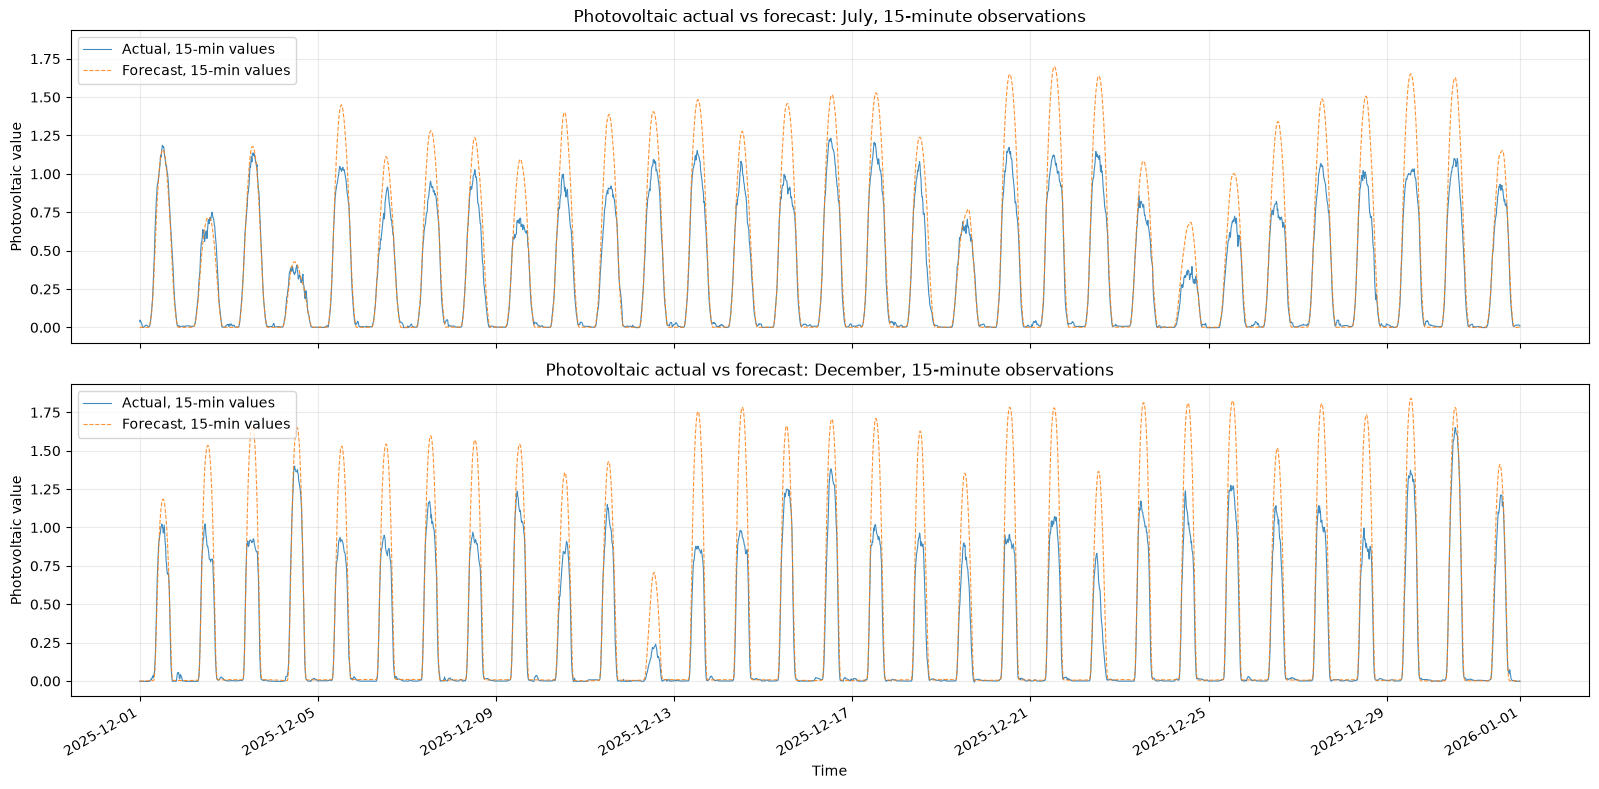

Saved: /Users/lenovo/Desktop/GRIPS2026_Project/output/EDA_figures/photovoltaic/photovoltaic_july_december_15min.png


In [6]:
# Plot 2: direct 15-minute photovoltaic values in July and December.
# No aggregation is applied here; each line follows the original 15-minute observations.

months_to_zoom = [(7, "July"), (12, "December")]
fig, axes = plt.subplots(len(months_to_zoom), 1, figsize=(16, 8), sharey=True)

for ax, (month_number, month_name) in zip(axes, months_to_zoom):
    month_data = pv_df[pv_df[TIME_COL].dt.month == month_number]

    if month_data.empty:
        ax.text(
            0.5,
            0.5,
            f"No {month_name} data found",
            transform=ax.transAxes,
            ha="center",
            va="center",
        )
        ax.set_title(f"{month_name}: no data")
        ax.grid(True, alpha=0.25)
        continue

    ax.plot(
        month_data[TIME_COL],
        month_data[PV_ACTUAL_COL],
        label="Actual, 15-min values",
        color="#1f77b4",
        linestyle="-",
        linewidth=0.8,
        alpha=0.85,
    )
    ax.plot(
        month_data[TIME_COL],
        month_data[PV_FORECAST_COL],
        label="Forecast, 15-min values",
        color="#ff7f0e",
        linestyle="--",
        linewidth=0.8,
        alpha=0.85,
    )

    ax.set_title(f"Photovoltaic actual vs forecast: {month_name}, 15-minute observations")
    ax.set_xlabel("Time")
    ax.set_ylabel("Photovoltaic value")
    ax.grid(True, alpha=0.25)
    ax.legend()

fig.autofmt_xdate()
fig.tight_layout()

seasonal_zoom_path = PV_PLOT_DIR / "photovoltaic_july_december_15min.png"
fig.savefig(seasonal_zoom_path, dpi=160)
plt.show()

print(f"Saved: {seasonal_zoom_path}")

## Hydropower actual vs forecast: February and August 15-minute zoom

This section focuses only on `Hydropower_Actual_Value` and `Hydropower_Forecast_Value`. No daily aggregation is used here; the plots show the original 15-minute observations for February and August.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_file_for_hydro(relative_path):
    relative_path = Path(relative_path)
    for base_path in [Path.cwd(), *Path.cwd().parents]:
        candidate = base_path / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {relative_path} from current directory: {Path.cwd()}")


HYDRO_DATA_PATH = find_project_file_for_hydro("raw_data/targets/preduction.csv")
PROJECT_ROOT = HYDRO_DATA_PATH.parents[2]
HYDRO_PLOT_DIR = PROJECT_ROOT / "output" / "EDA_figures" / "hydropower"
HYDRO_PLOT_DIR.mkdir(parents=True, exist_ok=True)

TIME_COL = "times"
HYDRO_ACTUAL_COL = "Hydropower_Actual_Value"
HYDRO_FORECAST_COL = "Hydropower_Forecast_Value"
HYDRO_COLS = [HYDRO_ACTUAL_COL, HYDRO_FORECAST_COL]

hydro_df = pd.read_csv(HYDRO_DATA_PATH)
missing_cols = [col for col in [TIME_COL, *HYDRO_COLS] if col not in hydro_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

hydro_df[TIME_COL] = pd.to_datetime(hydro_df[TIME_COL])
for col in HYDRO_COLS:
    hydro_df[col] = pd.to_numeric(hydro_df[col], errors="coerce")

hydro_df = hydro_df[[TIME_COL, *HYDRO_COLS]].sort_values(TIME_COL).dropna(subset=[TIME_COL])

print(f"Loaded: {HYDRO_DATA_PATH}")
print(f"Rows: {len(hydro_df):,}")
print(f"Time range: {hydro_df[TIME_COL].min()} to {hydro_df[TIME_COL].max()}")
hydro_df.head()

Loaded: /Users/lenovo/Desktop/GRIPS2026_Project/raw_data/targets/preduction.csv
Rows: 35,039
Time range: 2025-01-01 00:15:00 to 2025-12-31 23:45:00


,times,Hydropower_Actual_Value,Hydropower_Forecast_Value
0,2025-01-01 00:15:00,-0.009010,0.090382
1,2025-01-01 00:30:00,-0.030981,0.048798
2,2025-01-01 00:45:00,-0.036142,0.008617
3,2025-01-01 01:00:00,-0.048198,0.023098
4,2025-01-01 01:15:00,-0.049977,0.035371


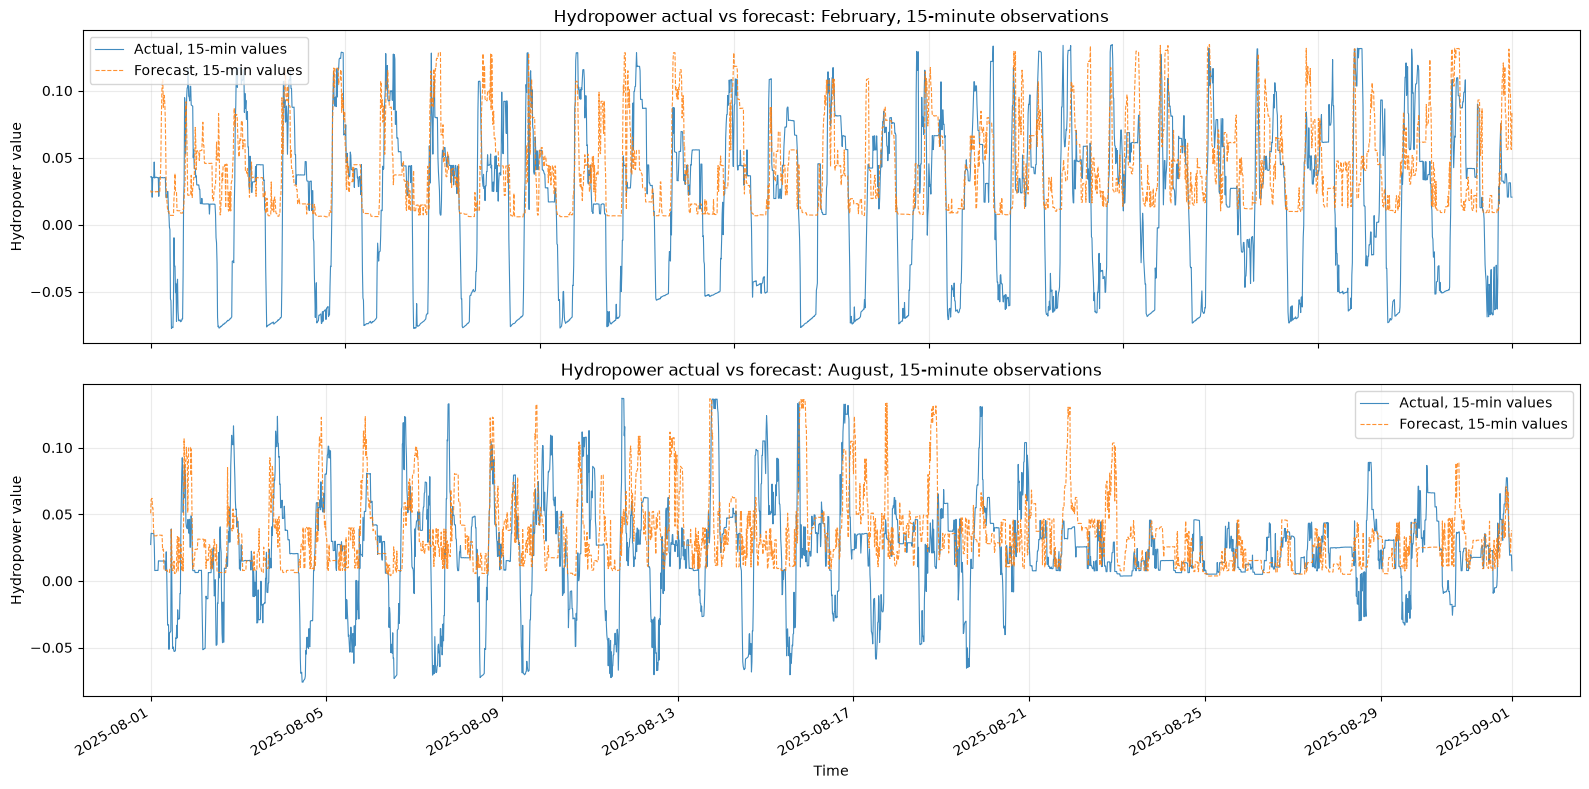

Saved: /Users/lenovo/Desktop/GRIPS2026_Project/output/EDA_figures/hydropower/hydropower_february_august_15min.png


In [8]:
# Direct 15-minute hydropower values in February and August.
# Each subplot uses its own y-axis scale to avoid one month making the other look compressed.

hydro_months_to_zoom = [(2, "February"), (8, "August")]
fig, axes = plt.subplots(len(hydro_months_to_zoom), 1, figsize=(16, 8), sharey=False)

for ax, (month_number, month_name) in zip(axes, hydro_months_to_zoom):
    month_data = hydro_df[hydro_df[TIME_COL].dt.month == month_number]

    if month_data.empty:
        ax.text(
            0.5,
            0.5,
            f"No {month_name} data found",
            transform=ax.transAxes,
            ha="center",
            va="center",
        )
        ax.set_title(f"{month_name}: no data")
        ax.grid(True, alpha=0.25)
        continue

    ax.plot(
        month_data[TIME_COL],
        month_data[HYDRO_ACTUAL_COL],
        label="Actual, 15-min values",
        color="#1f77b4",
        linestyle="-",
        linewidth=0.8,
        alpha=0.85,
    )
    ax.plot(
        month_data[TIME_COL],
        month_data[HYDRO_FORECAST_COL],
        label="Forecast, 15-min values",
        color="#ff7f0e",
        linestyle="--",
        linewidth=0.8,
        alpha=0.85,
    )

    ax.set_title(f"Hydropower actual vs forecast: {month_name}, 15-minute observations")
    ax.set_xlabel("Time")
    ax.set_ylabel("Hydropower value")
    ax.grid(True, alpha=0.25)
    ax.legend()

fig.autofmt_xdate()
fig.tight_layout()

hydro_zoom_path = HYDRO_PLOT_DIR / "hydropower_february_august_15min.png"
fig.savefig(hydro_zoom_path, dpi=160)
plt.show()

print(f"Saved: {hydro_zoom_path}")